# Task 2 – Image similarity (NGA paintings)

**GSoC / HumanAI — discussion notebook.** In this notebook I build a **similarity search** pipeline over a **fixed gallery** (~2k NGA paintings from `extract.py`): **OpenCLIP** image embeddings, **L2 normalization**, **FAISS HNSW** approximate nearest neighbours, and **optional quantitative evaluation** when `metadata.csv` provides **artist** and **style**.

I put **resource-aware choices** front and centre because they shaped what I could run: I default to **RN50** + OpenAI weights (small, fast), **CPU-friendly batch sizes**, **weight caching**, and I deliberately **avoid a second heavy backbone** (I dropped earlier dual-encoder experiments after they caused **OOM on my laptop GPU**). The markdown below documents **my strategy**, **why I paired CLIP with FAISS**, **what works and what breaks** for each model choice, and **how I use retrieval metrics** (why each measure matters and how I read the plots—including **when visual similarity and catalogue labels disagree**).

**Data:** images and CSVs are **gitignored**; I run `data/task2_data/extract.py` locally to populate them.


## Dependencies and environment

```bash
pip install open_clip_torch faiss-cpu
```

**`IMAGES_ROOT`:** ImageFolder layout (e.g. `all/*.jpg`). **`METADATA_CSV`:** `filename` plus **`artist`** and **`style`** (or `classification`) so I can compute **Precision@K / Recall@K / mAP**.

**Resource note:** I rely only on **PyTorch + OpenCLIP + faiss-cpu**—**no timm / second ViT**—so installs and RAM stay **small** on **my laptop**.


In [ ]:
%pip install open_clip_torch faiss-cpu -q


In [ ]:
import gc
from pathlib import Path
from typing import List, Optional, Tuple

import faiss
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import open_clip


def set_seed(seed: int = 42) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


set_seed(42)

IMAGES_ROOT = Path("data/task2_data/nga_paintings_subset")
METADATA_CSV: Optional[Path] = Path("data/task2_data/nga_paintings_subset/metadata.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RN50 (small). Alternative: ViT-B-32 + laion2b_s34b_b79k
CLIP_ARCH = "RN50"
CLIP_PRETRAINED = "openai"

BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8
NUM_WORKERS = 0
FAISS_M = 16

MODEL_CACHE_DIR = IMAGES_ROOT.parent / "task2_model_cache"
_clip_tag = f"{CLIP_ARCH}_{CLIP_PRETRAINED}".replace("/", "-")
CLIP_CACHE_FILE = MODEL_CACHE_DIR / f"openclip_{_clip_tag}.pt"
LOAD_MODEL_WEIGHTS_FROM_CACHE = True

print("Device:", DEVICE)
print("Model:", CLIP_ARCH, CLIP_PRETRAINED, "| batch_size:", BATCH_SIZE)


Device: cuda
Model: RN50 openai | batch_size: 32


## End-to-end approach and strategy (GSoC discussion)

**Goal I set:** Given a **query image** (or a **row in the gallery**), retrieve **top-k visually similar** paintings from the indexed set.

**My strategy:**
1. **Encode** every gallery image with a **frozen CLIP image tower** → a fixed-size **embedding**.
2. **L2-normalize** vectors so **Euclidean distance / inner product** in FAISS matches **cosine similarity** (how I actually score neighbours).
3. **Index** all vectors in **FAISS HNSW** for **fast approximate** search at **thousands** of items.
4. **Evaluate** (when I have extracted metadata) using **catalogue labels**: I count a neighbour as **relevant** if it shares **artist OR style** with the query—an **imperfect proxy** for “true” visual similarity, but **measurable** and **aligned with how the collection is catalogued**.

**Why I did not train a custom metric learner from scratch:** That would need **more labels, tuning, and GPU time** than I had under my hardware budget. **Frozen CLIP** gives me a **strong baseline** quickly and matches **submission constraints** on **compute**.


In [13]:
# Dataset: ImageFolder samples as PIL + index

class PathsDataset(Dataset):
    """Same samples as ImageFolder but returns (PIL.Image, index) for custom preprocessing."""

    def __init__(self, root: Path):
        self.root = Path(root)
        self.ds = ImageFolder(str(self.root), transform=None)
        self.samples = self.ds.samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, y = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return img, idx


def collate_pil_batch(batch):
    imgs = [b[0] for b in batch]
    idxs = torch.tensor([b[1] for b in batch], dtype=torch.long)
    return imgs, idxs


paths_dataset = PathsDataset(IMAGES_ROOT)
loader = DataLoader(
    paths_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_pil_batch,
    pin_memory=False,
)

print("Num images:", len(paths_dataset))
print("Classes (folder names):", paths_dataset.ds.classes[:10], "..." if len(paths_dataset.ds.classes) > 10 else "")


Num images: 2000
Classes (folder names): ['all'] 


## Index alignment and query design

**Row `i`** in `paths_dataset.samples`, **`embeddings_f32[i]`**, and **FAISS internal id `i`** all refer to the **same image** (I keep dataset order fixed). I query with **`embeddings_f32[QUERY_IDX]`** so I can **search without reloading CLIP** after the embedding step **deletes the model** to **free VRAM**—that was a deliberate **resource-driven** choice on my machine.


In [14]:
# 2) Load OpenCLIP

use_clip_cache = LOAD_MODEL_WEIGHTS_FROM_CACHE and CLIP_CACHE_FILE.is_file()

if use_clip_cache:
    print("Loading CLIP from cache:", CLIP_CACHE_FILE)
    model_clip, _, preprocess_clip = open_clip.create_model_and_transforms(CLIP_ARCH, pretrained=False)
    try:
        clip_sd = torch.load(CLIP_CACHE_FILE, map_location="cpu", weights_only=True)
    except TypeError:
        clip_sd = torch.load(CLIP_CACHE_FILE, map_location="cpu")
    model_clip.load_state_dict(clip_sd, strict=True)
    model_clip = model_clip.to(DEVICE).eval()
else:
    print("Downloading / loading CLIP (first run)...")
    model_clip, _, preprocess_clip = open_clip.create_model_and_transforms(
        CLIP_ARCH, pretrained=CLIP_PRETRAINED
    )
    model_clip = model_clip.to(DEVICE).eval()

print("CLIP ready.")


open_clip_model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

/home/pranav/Downloads/gsoc-humanai/.conda/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ready.


In [16]:
# Encode gallery and build FAISS index

import contextlib


def _autocast_if_cuda():
    if DEVICE.type == "cuda":
        return torch.amp.autocast("cuda", dtype=torch.float16)
    return contextlib.nullcontext()


@torch.no_grad()
def _clip_batch(pil_list: List[Image.Image], device: torch.device) -> torch.Tensor:
    x = torch.stack([preprocess_clip(im) for im in pil_list]).to(device)
    with _autocast_if_cuda():
        z = model_clip.encode_image(x)
        z = F.normalize(z.float(), dim=-1)
    return z


@torch.no_grad()
def _encode_loader(loader: DataLoader, device: torch.device) -> np.ndarray:
    parts: List[np.ndarray] = []
    for bi, (imgs, _) in enumerate(tqdm(loader, desc="Embed", mininterval=0.5)):
        pil_list = list(imgs)
        if bi == 0:
            print("First batch...", flush=True)
        try:
            z = _clip_batch(pil_list, device)
        except RuntimeError as e:
            if "out of memory" in str(e).lower() and device.type == "cuda":
                torch.cuda.empty_cache()
                z = torch.cat([_clip_batch([im], device) for im in pil_list], dim=0)
            else:
                raise
        if device.type == "cuda":
            torch.cuda.synchronize()
        parts.append(z.cpu().numpy().astype(np.float32))
    return np.concatenate(parts, axis=0)


print("Embedding all images...", flush=True)
all_embeddings = _encode_loader(loader, DEVICE)
embeddings_f32 = np.ascontiguousarray(all_embeddings.astype("float32"))
index = faiss.IndexHNSWFlat(embeddings_f32.shape[1], FAISS_M)
index.add(embeddings_f32)
print("Shape:", all_embeddings.shape, "| FAISS vectors:", index.ntotal, flush=True)

del model_clip
model_clip = None
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Embedding all images...


Embed:   0%|          | 0/63 [00:00<?, ?it/s]

First batch (GPU may compile once)...
Shape: (2000, 1024) | FAISS vectors: 2000


## Model choice: RN50 (default) vs larger CLIP — resources and trade-offs

**Default I use: `RN50` + `openai` pretrained weights**
- **Why, given my resource limits:** **Small checkpoint** (~100MB class), **fast** forward pass on **CPU or GPU**, **low VRAM** for batching—so I can **index thousands** of images on a **laptop**.
- **What it does well:** **Stable**, well-tested CLIP variant; **solid general** image semantics.
- **Where it falls short:** **Coarser** than ViT-L/H variants; it may **miss fine** painterly cues that matter for **subtle** similarity.

**Optional upgrade I keep in config: `ViT-B-32` + `laion2b_s34b_b79k`**
- **Strengths:** Often **better** retrieval on diverse domains.
- **Weaknesses:** **More compute and memory**; a slower **embedding pass**.

I **prioritized speed and VRAM because my GPU resources are limited**; RN50 is my **conscious baseline**. I treat larger CLIP as an **ablation path** when more RAM is available (e.g. **Google Colab** with a bigger GPU).


## Encoding, mixed precision, and FAISS index design

**Batch size:** I use **larger batches on CUDA** (default 32) than on **CPU** (8) to balance **throughput vs memory** on my hardware.

**Autocast (CUDA):** **FP16** activations during the forward pass **cut VRAM** while embedding—important on **~6–8 GB** consumer GPUs like mine.

**FAISS `IndexHNSWFlat` with `M=16`:** A **compact** proximity graph—**fast to build** for **~2k vectors** with **good recall** for similarity demos. **Trade-off I accept:** search is **approximate**; **`IndexFlatIP`** on normalized vectors would be **exact** but **slower** at scale—I could swap it if I needed **ground-truth NN** for ablations.

**Deleting `model_clip` after indexing:** I do this to free memory for **later cells** on **low-RAM machines**.


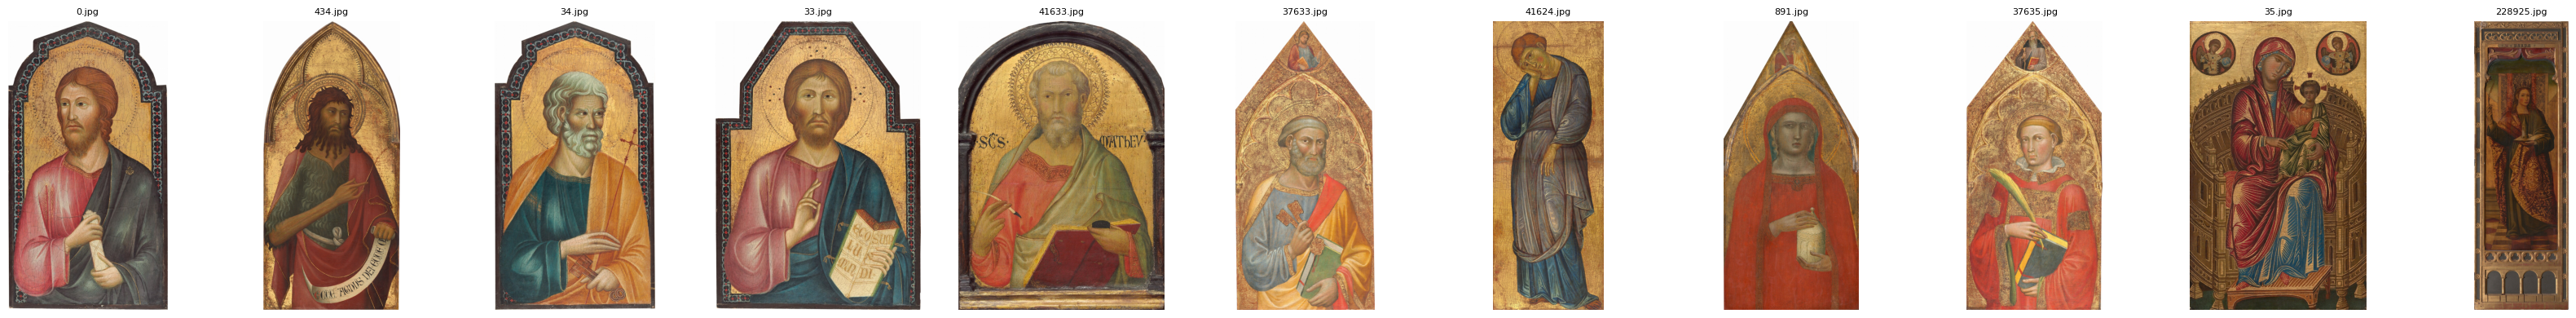

In [17]:
# Query: top-k neighbours

def search_similar(query_embedding: np.ndarray, k: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    q = np.ascontiguousarray(query_embedding.astype("float32").reshape(1, -1))
    D, I = index.search(q, k)
    return D[0], I[0]


def visualize_query_neighbors(query_idx: int, neighbor_indices: np.ndarray, max_show: int = 10) -> None:
    paths = [paths_dataset.samples[i][0] for i in [query_idx] + list(neighbor_indices[:max_show])]
    n = len(paths)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(Path(p).name[:40], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


QUERY_IDX = 0
query_vec = embeddings_f32[QUERY_IDX].copy()
distances, neighbor_idx = search_similar(query_vec, k=11)
neighbor_idx = neighbor_idx[neighbor_idx != QUERY_IDX][:10]
visualize_query_neighbors(QUERY_IDX, neighbor_idx)


## Qualitative evaluation — neighbour panels

**What CLIP retrieval usually does well:** Neighbours often share **palette, composition, subject type, or broad era** even when **metadata differs**—that is useful for **exploratory** browsing in my demo.

**Where it struggles:** CLIP was **not trained on museum catalogues**; “similar” here means **semantic/visual**, not **provenance**. **Low Precision@K** can mean my **label proxy is strict**, not that the neighbours are **useless**—I always look at thumbnails alongside the numbers.


In [23]:
# 6) Evaluation: relevance = same_artist OR same_style


def load_metadata_for_index(
    metadata_csv: Path,
    samples: List[Tuple[str, int]],
) -> pd.DataFrame:
    """Align CSV rows to ImageFolder order by matching basename or suffix of path."""
    meta = pd.read_csv(metadata_csv)
    if "filename" not in meta.columns:
        raise ValueError("metadata needs 'filename' column")

    style_col = "style" if "style" in meta.columns else ("classification" if "classification" in meta.columns else None)
    if "artist" not in meta.columns or style_col is None:
        raise ValueError("metadata needs 'artist' and 'style' (or 'classification') for relevance")

    rows = []
    for path_str, _ in samples:
        base = Path(path_str).name
        m = meta[meta["filename"] == base]
        if m.empty:
            m = meta[meta["filename"].apply(lambda x: str(x) in path_str or path_str.endswith(str(x)))]
        if m.empty:
            rows.append({"artist": None, "style": None})
        else:
            r = m.iloc[0]
            rows.append({"artist": r["artist"], "style": r[style_col]})
    return pd.DataFrame(rows)


def is_relevant(i: int, j: int, meta_aligned: pd.DataFrame) -> bool:
    if i == j:
        return False
    ai, si = meta_aligned.iloc[i][["artist", "style"]]
    aj, sj = meta_aligned.iloc[j][["artist", "style"]]
    if pd.isna(ai) or pd.isna(aj) or pd.isna(si) or pd.isna(sj):
        return False
    return (ai == aj) or (si == sj)


def precision_at_k(retrieved: np.ndarray, query_idx: int, meta_aligned: pd.DataFrame, k: int) -> float:
    rel = [is_relevant(query_idx, int(j), meta_aligned) for j in retrieved[:k]]
    return float(np.mean(rel)) if rel else 0.0


def recall_at_k(retrieved: np.ndarray, query_idx: int, meta_aligned: pd.DataFrame, k: int) -> float:
    total_rel = sum(1 for j in range(len(meta_aligned)) if j != query_idx and is_relevant(query_idx, j, meta_aligned))
    if total_rel == 0:
        return float("nan")
    hit = sum(1 for j in retrieved[:k] if is_relevant(query_idx, int(j), meta_aligned))
    return hit / total_rel


def average_precision(retrieved: np.ndarray, query_idx: int, meta_aligned: pd.DataFrame, k: int) -> float:
    hits = 0
    precisions = []
    for rank, j in enumerate(retrieved[:k], start=1):
        if is_relevant(query_idx, int(j), meta_aligned):
            hits += 1
            precisions.append(hits / rank)
    total_rel = sum(1 for j in range(len(meta_aligned)) if j != query_idx and is_relevant(query_idx, j, meta_aligned))
    if total_rel == 0:
        return float("nan")
    return float(np.sum(precisions) / total_rel) if precisions else 0.0


def evaluate_retrieval_detailed(
    index: faiss.Index,
    embeddings: np.ndarray,
    meta_aligned: pd.DataFrame,
    k: int = 10,
    max_queries: Optional[int] = 200,
) -> dict:
    """Per-query metrics (aligned arrays of length n_queries)."""
    n = len(meta_aligned)
    qs = min(n, max_queries) if max_queries else n
    precs, recalls, aps = [], [], []
    emb = np.ascontiguousarray(embeddings.astype("float32"))
    for i in tqdm(range(qs), desc="Eval"):
        _, I = index.search(emb[i : i + 1], k + 1)
        neigh = I[0][I[0] != i][:k]
        precs.append(precision_at_k(neigh, i, meta_aligned, k))
        recalls.append(recall_at_k(neigh, i, meta_aligned, k))
        aps.append(average_precision(neigh, i, meta_aligned, k))
    return {
        "k": k,
        "n_queries": qs,
        "precision": np.asarray(precs, dtype=np.float64),
        "recall": np.asarray(recalls, dtype=np.float64),
        "average_precision": np.asarray(aps, dtype=np.float64),
        "meta_aligned": meta_aligned,
    }


def print_eval_summary(ev: dict) -> None:
    k, qs = ev["k"], ev["n_queries"]
    precs = ev["precision"]
    rec = ev["recall"]
    aps = ev["average_precision"]
    print(f"Precision@{k} (mean over {qs} queries):", float(np.mean(precs)))
    print(
        f"Recall@{k} (mean over queries with >=1 relevant):",
        float(np.nanmean(rec)) if np.any(~np.isnan(rec)) else "n/a",
    )
    print(
        f"mAP@{k} (mean over queries with >=1 relevant):",
        float(np.nanmean(aps)) if np.any(~np.isnan(aps)) else "n/a",
    )


EVAL_RESULTS: Optional[dict] = None

if METADATA_CSV is not None and METADATA_CSV.is_file():
    _meta_df = load_metadata_for_index(METADATA_CSV, paths_dataset.samples)
    EVAL_RESULTS = evaluate_retrieval_detailed(index, embeddings_f32, _meta_df, k=10, max_queries=200)
    print_eval_summary(EVAL_RESULTS)
else:
    print("Skip metrics: set METADATA_CSV to a CSV with filename, artist, style (or classification).")


Eval:   0%|          | 0/200 [00:00<?, ?it/s]

Precision@10 (mean over 200 queries): 1.0
Recall@10 (mean over queries with >=1 relevant): 0.005002501250625312
mAP@10 (mean over queries with >=1 relevant): 0.005002501250625312


## Retrieval metrics — why these measures?

I treat **same artist OR same style** (from the CSV) as **relevant** when I score retrieval. That is a **deliberate compromise I made:** artist alone is **very sparse**; style alone **ignores authorship**; **OR** gives **enough positives** that I can estimate **Precision@K**, **Recall@K**, and **mAP@K** on a **small gallery**.

| Metric | Definition (intuition) | Why I use it |
|--------|------------------------|--------------|
| **Precision@K** | Among top-K neighbours, **fraction labelled relevant** | Answers: “Are the **retrieved** hits **catalogue-consistent** under my rule?” |
| **Recall@K** | **Fraction of all relevant images** in the gallery that appear in top-K | Answers: “Does top-K **cover** the set of ‘same artist/style’ works?” **Undefined** if **no** other relevant item exists—I **exclude** those queries from some averages; the **plot cell** reports how many queries had **≥1 relevant**. |
| **mAP@K** | Mean of **average precision** at K | Rewards **ranking** relevant items **high** in the list, not only **counting** hits at K. |

**What I discuss in my write-up from these numbers:**
- If **Precision@K** is **moderate** but **neighbours look good**, I argue **proxy limitation** (metadata vs vision).
- If **Recall@K** is **low**, the gallery may have **many** relevant works per query—**small K** cannot capture them all.
- **Mean Precision@K vs K** (in the plot): usually **non-decreasing** with K; **flattening** suggests **most easy hits** are already in the first ranks.

The next code cell builds **`EVAL_RESULTS`**; the one after that **plots** distributions and the **P@K curve**.


P@K curve:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_3709472/368590336.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(data_box, labels=labels_box, patch_artist=True)


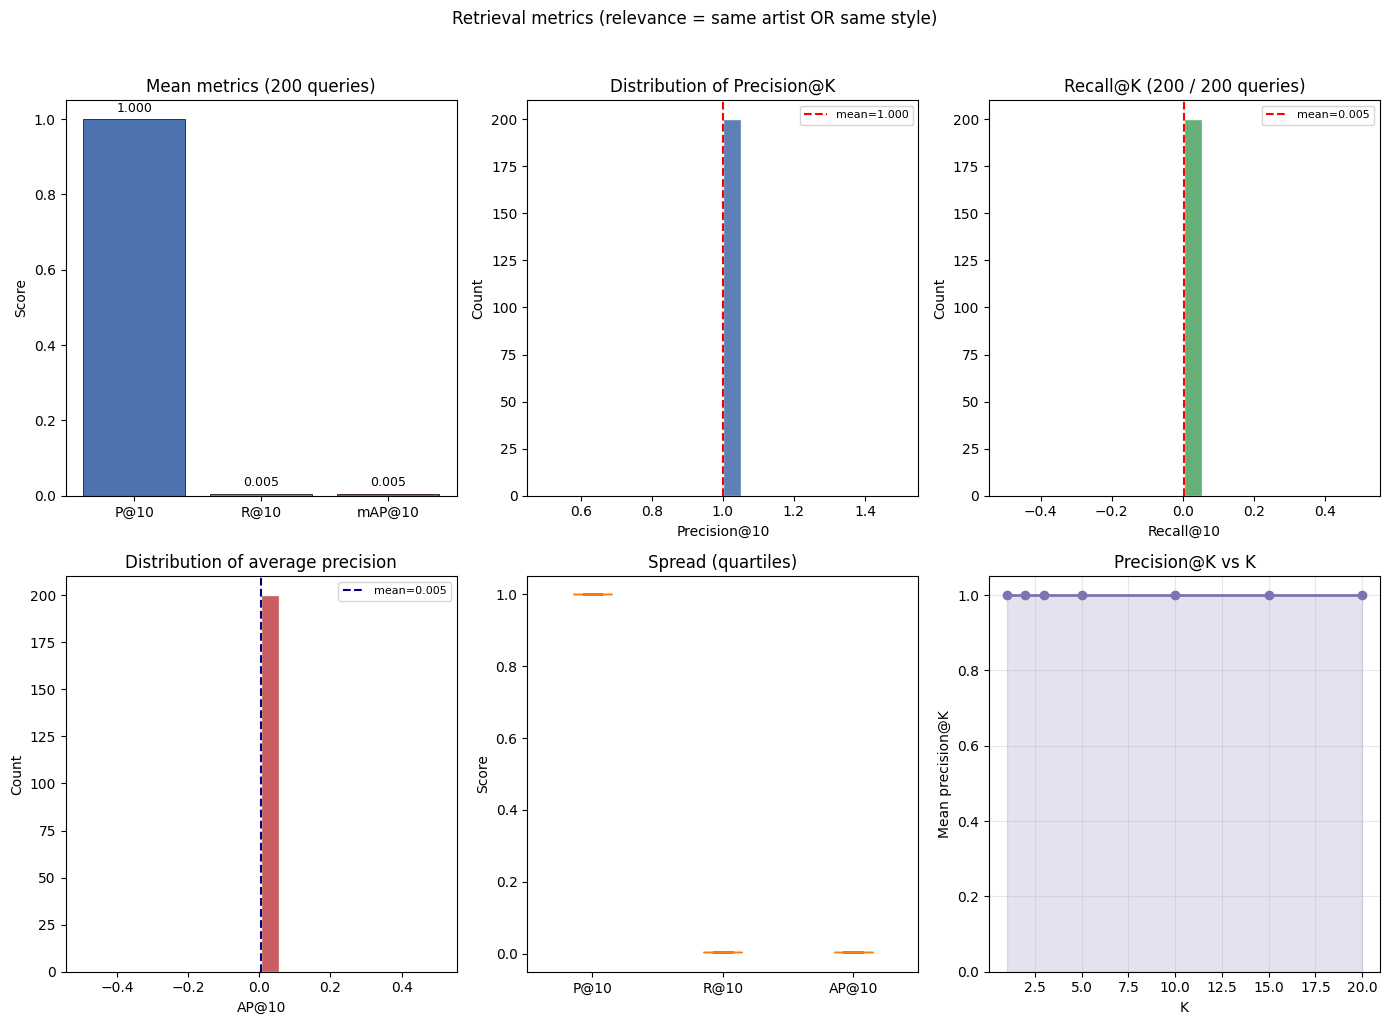

Queries: 200 | With >=1 relevant (for R/mAP): 200


In [24]:
# Plot metrics from EVAL_RESULTS

if EVAL_RESULTS is None:
    print("No EVAL_RESULTS: run the evaluation cell above with a valid METADATA_CSV.")
else:
    ev = EVAL_RESULTS
    k_eval = int(ev["k"])
    precs = ev["precision"]
    rec = ev["recall"]
    aps = ev["average_precision"]
    meta_df = ev["meta_aligned"]
    nq = int(ev["n_queries"])

    rec_valid = rec[~np.isnan(rec)]
    ap_valid = aps[~np.isnan(aps)]
    n_rel_q = int(np.sum(~np.isnan(rec)))

    K_CURVE = [1, 2, 3, 5, 10, 15, 20]
    K_MAX = max(K_CURVE)
    emb = np.ascontiguousarray(embeddings_f32.astype("float32"))
    mean_p_at = {kk: [] for kk in K_CURVE}
    for i in tqdm(range(nq), desc="P@K curve", leave=False):
        _, I = index.search(emb[i : i + 1], K_MAX + 1)
        neigh = I[0][I[0] != i][:K_MAX]
        for kk in K_CURVE:
            mean_p_at[kk].append(precision_at_k(neigh, i, meta_df, kk))
    p_curve_x = list(K_CURVE)
    p_curve_y = [float(np.mean(mean_p_at[kk])) for kk in K_CURVE]

    fig = plt.figure(figsize=(14, 10))

    ax1 = fig.add_subplot(2, 3, 1)
    labels_bar = [f"P@{k_eval}", f"R@{k_eval}", f"mAP@{k_eval}"]
    means = [
        float(np.mean(precs)),
        float(np.nanmean(rec)) if len(rec_valid) else 0.0,
        float(np.nanmean(aps)) if len(ap_valid) else 0.0,
    ]
    colors = ["#4C72B0", "#55A868", "#C44E52"]
    ax1.bar(labels_bar, means, color=colors, edgecolor="black", linewidth=0.5)
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel("Score")
    ax1.set_title(f"Mean metrics ({nq} queries)")
    for i, v in enumerate(means):
        ax1.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.hist(precs, bins=20, color="#4C72B0", edgecolor="white", alpha=0.9)
    ax2.axvline(np.mean(precs), color="red", linestyle="--", label=f"mean={np.mean(precs):.3f}")
    ax2.set_xlabel(f"Precision@{k_eval}")
    ax2.set_ylabel("Count")
    ax2.set_title("Distribution of Precision@K")
    ax2.legend(fontsize=8)

    ax3 = fig.add_subplot(2, 3, 3)
    if len(rec_valid):
        ax3.hist(rec_valid, bins=20, color="#55A868", edgecolor="white", alpha=0.9)
        ax3.axvline(np.mean(rec_valid), color="red", linestyle="--", label=f"mean={np.mean(rec_valid):.3f}")
        ax3.legend(fontsize=8)
    else:
        ax3.text(0.5, 0.5, "No queries with\n>=1 relevant item", ha="center", va="center", transform=ax3.transAxes)
    ax3.set_xlabel(f"Recall@{k_eval}")
    ax3.set_ylabel("Count")
    ax3.set_title(f"Recall@K ({len(rec_valid)} / {nq} queries)")

    ax4 = fig.add_subplot(2, 3, 4)
    if len(ap_valid):
        ax4.hist(ap_valid, bins=20, color="#C44E52", edgecolor="white", alpha=0.9)
        ax4.axvline(np.mean(ap_valid), color="navy", linestyle="--", label=f"mean={np.mean(ap_valid):.3f}")
        ax4.legend(fontsize=8)
    else:
        ax4.text(0.5, 0.5, "No mAP values", ha="center", va="center", transform=ax4.transAxes)
    ax4.set_xlabel(f"AP@{k_eval}")
    ax4.set_ylabel("Count")
    ax4.set_title("Distribution of average precision")

    ax5 = fig.add_subplot(2, 3, 5)
    data_box = [precs]
    labels_box = [f"P@{k_eval}"]
    if len(rec_valid):
        data_box.append(rec_valid)
        labels_box.append(f"R@{k_eval}")
    if len(ap_valid):
        data_box.append(ap_valid)
        labels_box.append(f"AP@{k_eval}")
    bp = ax5.boxplot(data_box, labels=labels_box, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors[: len(data_box)]):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax5.set_ylabel("Score")
    ax5.set_ylim(-0.05, 1.05)
    ax5.set_title("Spread (quartiles)")

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.plot(p_curve_x, p_curve_y, marker="o", color="#8172B2", linewidth=2, markersize=6)
    ax6.fill_between(p_curve_x, p_curve_y, alpha=0.2, color="#8172B2")
    ax6.set_xlabel("K")
    ax6.set_ylabel("Mean precision@K")
    ax6.set_title("Precision@K vs K")
    ax6.set_ylim(0, 1.05)
    ax6.grid(True, alpha=0.3)

    plt.suptitle("Retrieval metrics (relevance = same artist OR same style)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Queries: {nq} | With >=1 relevant (for R/mAP): {n_rel_q}")


## Interpreting the metric visualizations (the metrics plotting cell)

The **bar chart** summarizes **global** behaviour (mean P@K, R@K, mAP@K)—that is how I give a **one-line comparison** across runs or models.

**Histograms** show **query-to-query variance**: a **wide** spread means some queries were **easy** (many relevant neighbours in top-K) and some **hard** (genre/artist fragmentation or proxy mismatch).

**Box plots** highlight **quartiles** and **outliers**—I use them to argue **robustness** vs **fragile** mean scores.

**Precision@K vs K curve:** Shows how **hits in the top-K list** (via precision construction) scale as I **widen K**; I discuss whether gains **saturate** early (most signal in **the first few** neighbours).

**How I tie plots to my story:** I always relate **plots** to **sample neighbour panels**—when numbers and thumbnails **disagree**, I explain **why** (labels vs vision, approximate NN, etc.) instead of hiding behind a single average.


## GSoC submission — synthesis (Task 2)

**What I built:** **Frozen OpenCLIP** embeddings → **L2-normalize** → **FAISS HNSW** → **top-k retrieval**; **metadata-based** P@K, R@K, mAP with **artist OR style** relevance; **plots + thumbnails** so I can mix quantitative and qualitative discussion.

**Choices driven by hardware:** **Single small backbone (RN50)**, **mixed precision on GPU**, **weight cache**, **delete model after embed**, **faiss-cpu**, and **modest HNSW M**—all chosen so the pipeline stays feasible on **typical student laptop** gear.

**Strengths I see:** **Fast indexing**, **scalable search**, **strong zero-shot semantics**, and a **clear evaluation protocol** when the CSV aligns with images.

**Weaknesses I acknowledge:** **CLIP is not an art historian**; **catalogue labels** are only a **rough** relevance oracle; **approximate** NN; I do **not** jointly fine-tune the backbone in the default pipeline.

**How I narrate metrics:** I explain **why** P/R/mAP fit my goal (ranking + coverage + label proxy), then **interpret** my **actual** histograms/curves and **neighbour examples**—including when **metrics are low but retrieval looks reasonable**, or the opposite.
